<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/environment/SpectroscopyDataExtraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color='red'> Reduction and extraction of Spectroscopy data

**by Alejandro Benitez-Llambay (alejandro.benitezllambay@unimib.it)** for the lab on "Signal and Imaging Acquisition and Modelling in Environment", of the Master in Artificial Inteligence for Science and Technology (AI4ST) at UNIMIB. Data kindly provided by Prof. Fosatti


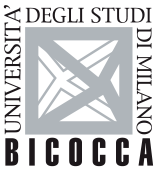

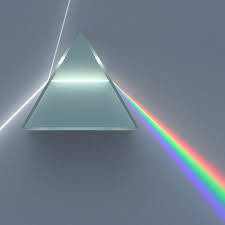

Today, we propose applying the standard image calibration pipeline studied in class to process spectroscopy astronomical images and preparing them for scientific measurements.

As discussed in class, the process of image reduction aims to remove the intrinsic instrument response (e.g., irregular spatial response due to dust or debris in the optical/detector system, inhomogeneities in the fabrication of individual pixels, electronic noise, etc.). Sometimes, it is also useful to correct for the detector's non-linearity, particularly if the detector contains saturated regions. However, we will not apply this correction today, as the detector is fairly linear below the saturation level.


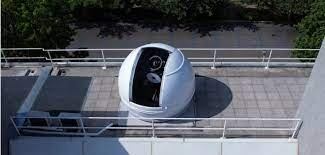

#The Data

We will be using images taken with the Bicocca Telescope. The dataset consists long slite spectroscopy images taken with the spectrograph mounter on the Bicocca Telescope.

The dataset is available here:

https://drive.google.com/drive/folders/1f0mJlBxaSSquXztqsBMxmkygX3HtJdoO?usp=sharing

The best way to work with these data is to create a shortcut in your Google Drive and then mount the drive here.

In the shared directory, you will find different subdirectories:

* **bias**: Contains the bias files requried for bias substraction.
* **flat**: Contains the files required for flat field correction.
* **arc**: Contains images of the spectrum of an Argon/Neon lamp.
* **science**: Contains images of the spectrum of an object together with the reduced spectrum of a standard star (.dat file).





#**YOUR TASK**

**Your task is to use the provided data to reduce and extract the spectroscopic observation.**

To achieve this, you need to:

1) **Obtain an accurate estimate of the bias (B).** This can be done by stacking several bias images.  

2) **Estimate the dark current rate (D).** This can be done by measuring the dark current using a long exposure and dividing by the integration time.  

3) **Estimate the flat-field correction (F)** that needs to be applied for each filter. This can be done by stacking several flat-field images.

With these data, the observed image can be corrected using the following equation:  

$S_{\rm red} = \frac{S_{\rm obs} - B - D \times \Delta t}{F}$  

where $S_{\rm red}$ is the reduced image, and $S_{\rm obs}$ is the image observed with the telescope and recorded by the CCD.

**Note**: before normalizing the flat field image as usual, you need to define a mask the select only the pixels of the slit image. **Only a small portion of the CDD is used to record the spectrum.**

Note that you can easily stack all the bias, and flat field correction images as follows (we won't correct for the dark current because the object is bright, and we the integration time short):

In [ ]:
path = #Use the path to your data here

bias_files = glob.glob(path+'/bias/*.fit')
flat_files = glob.glob(path+'/flat/*.fit')
arc_files = glob.glob(path+'/arc/*.fit')

masterbias = np.median([fits.getdata(inputfile)[:,:-5] for inputfile in bias_files], axis=0)
masterflat = np.median([fits.getdata(inputfile)[:,:-5] for inputfile in flat_files], axis=0)
masterarc  = np.median([fits.getdata(inputfile)[:,:-5] for inputfile in arc_files], axis=0)

masterflat = (masterflat - masterbias)
masterarc = (masterarc - masterbias)

#After you identify the mask containing the flat field image, you need to normalize the flat:

# masterflat = masterflat / np.median(masterflat[mask].flatten())


With these calibration images, you can now correct the observations as follow:

In [ ]:
#120 stands for the spectrum integrated with 120 seconds

science_120 = fits.getdata(path+'/science/HD3360_120s.fit')[:,:-5]
science_120 = science_120 - masterbias
science_120 = science_120 / masterflat_norm
science_120 /= 120 #To go from ADUs to ADUs/s, i.e., a rate

# **HINTS**

The mask for the image of the slit can be found using the flat images: For example:

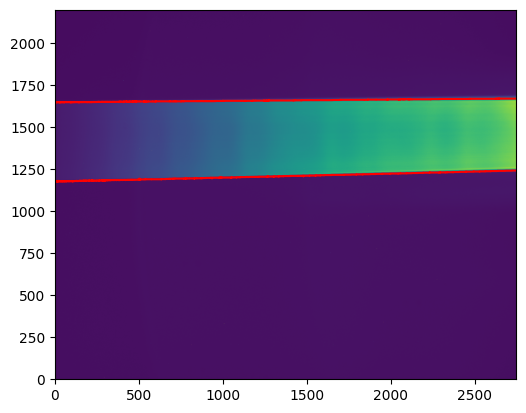

In which you need to find the edges applying a suitable algorithm (e.g., Sobel edge detection, or any other method). The results should produce a mask like this:

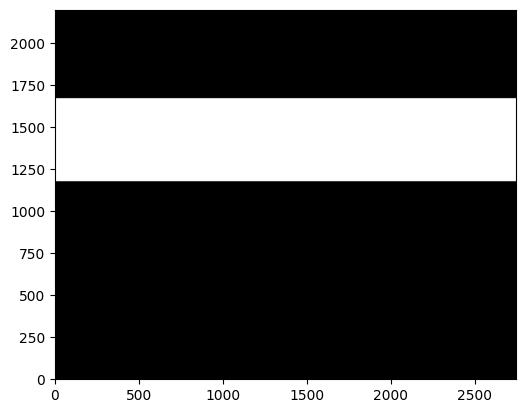

With this mask in hand, correct the images with the standard procedure.

Next, you need to trace the object along the CCD. For this, you can use the centroid of the object along the dispersion direction. A good trace should look like this:

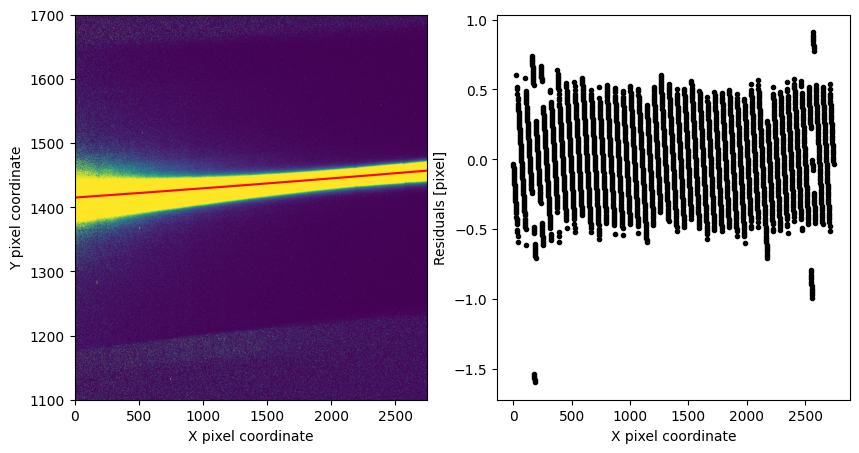

where the residulas refer to the difference between the centroid true location and the estimated locations traced by a polyonomial fit.

Next, with the object correctly traced, define the object's extent and the background. For example:

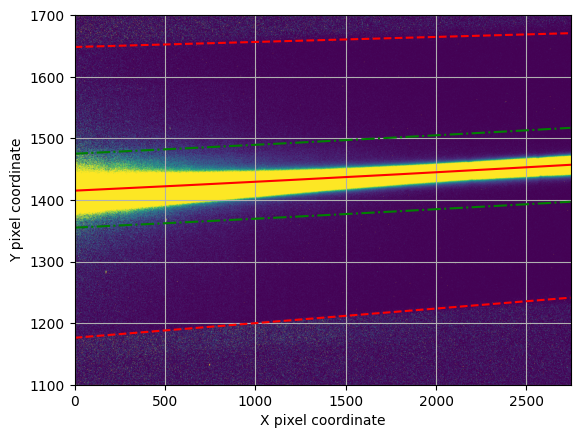

The object's spectrum can be extracted as the sum of the pixels over objetct's extent (green lines), as a function of $x$. This should look like this:

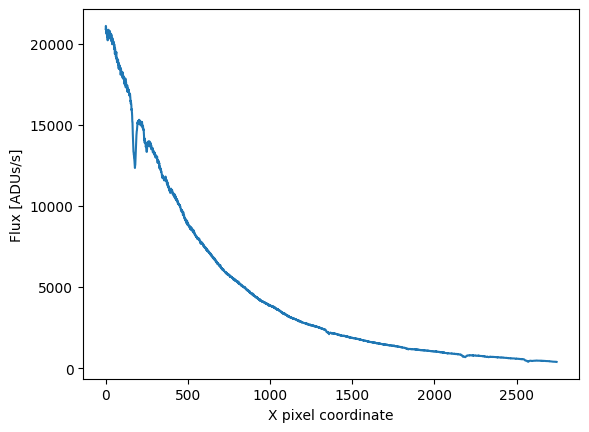

Next, we need to find a mapping between pixel coordinates and actual wavelenghts. For this, use the lamp spectrum files, extracting their spectrum as done for the object. E.g.,:

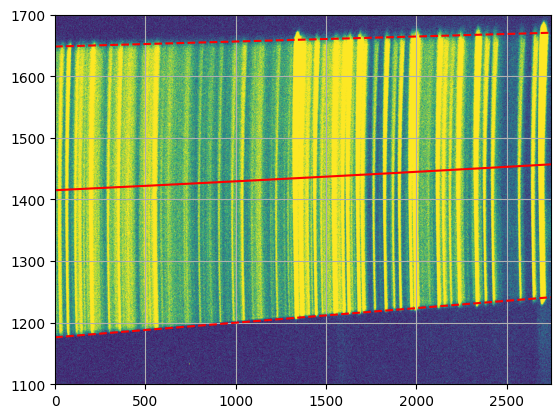

Extracting the specturm produces the following image, in which I have identified a few lines based on a thershold flux limit.

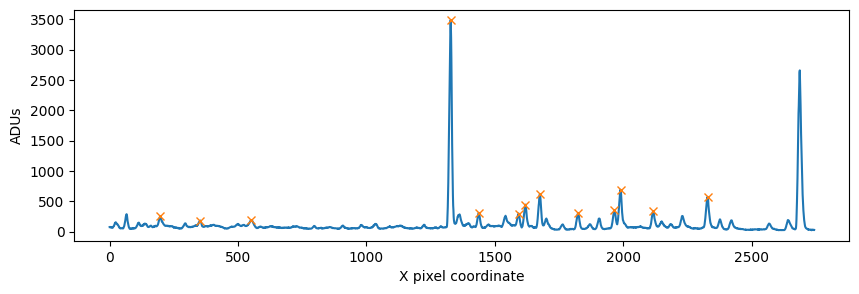

These lines can be compared agains those published in http://www.astrophoto.at/calibration-arne.html, and establish their true wavelength.

The transformation between pixel value and wavelength can be found by fitting a linear or second order function to these few lines. For example:

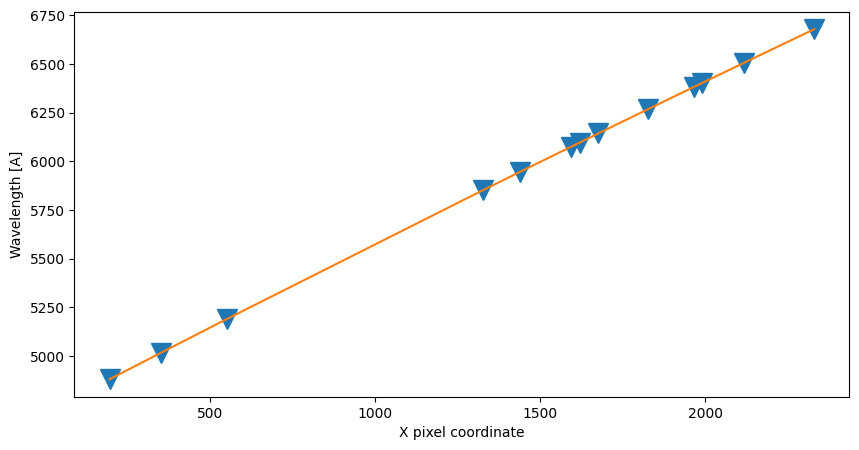

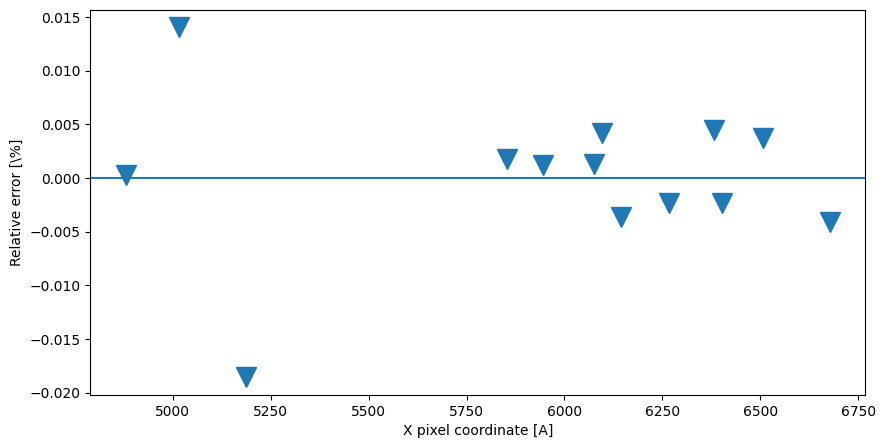

At the end of the process, the spectrum should look similar to:

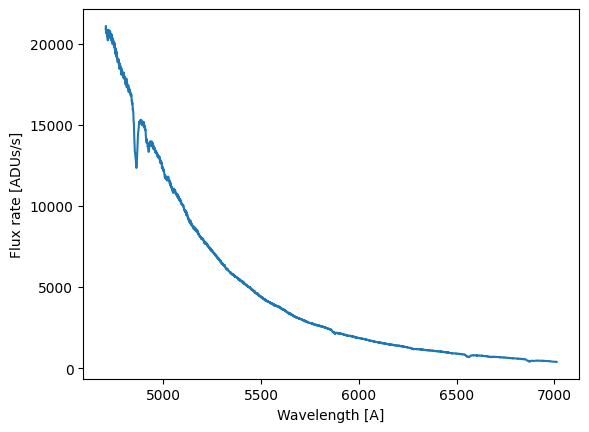

Finally, fitting a smooth function to the continnum emission allows to study the depth of absorption lines relative to the continnum level. For example:

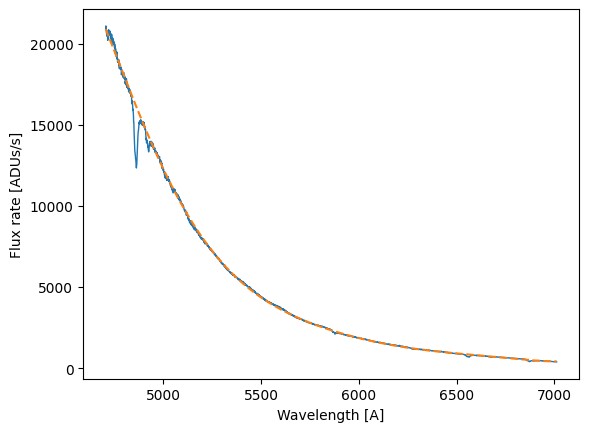

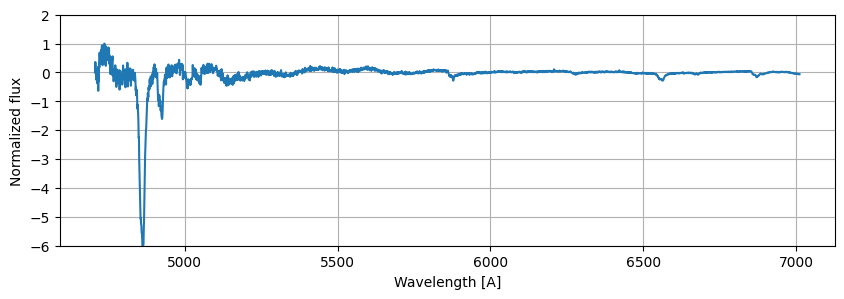


# Your code stars here:


In [1]:
from google.colab import drive
import glob
import numpy as np
from  astropy.io import fits
import matplotlib.pyplot as plt
import math
import os
import cv2

In [2]:
# load the dataset
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/Environment/Spectroscopy/data"

bias_files = glob.glob(path+'/bias/*.fit')
flat_files = glob.glob(path+'/flat/*.fit')
arc_files = glob.glob(path+'/arc/*.fit')


In [4]:
def plot_files_img(file_path):
  plt.figure(figsize=(12, 6))
  for i, bias_file in enumerate(file_path):
    plt.subplot(2, 3, i+1)
    image = fits.getdata(bias_file)
    plt.imshow(np.log10(image))
    title = os.path.basename(bias_file)
    plt.title(title)
  plt.tight_layout()
  plt.axis(False)


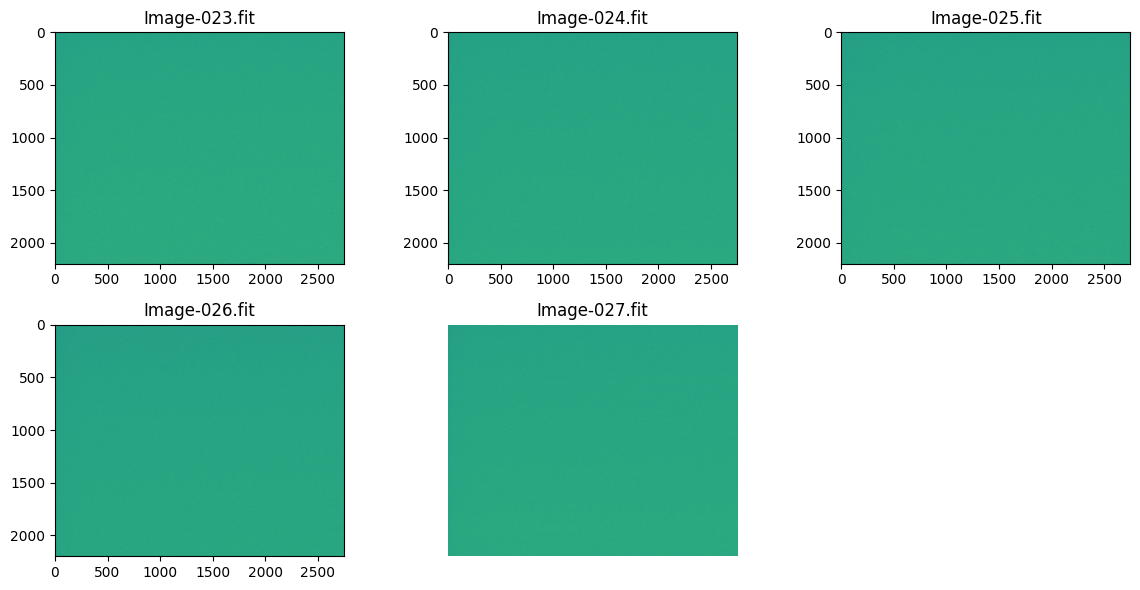

In [ ]:
plot_files_img(bias_files)

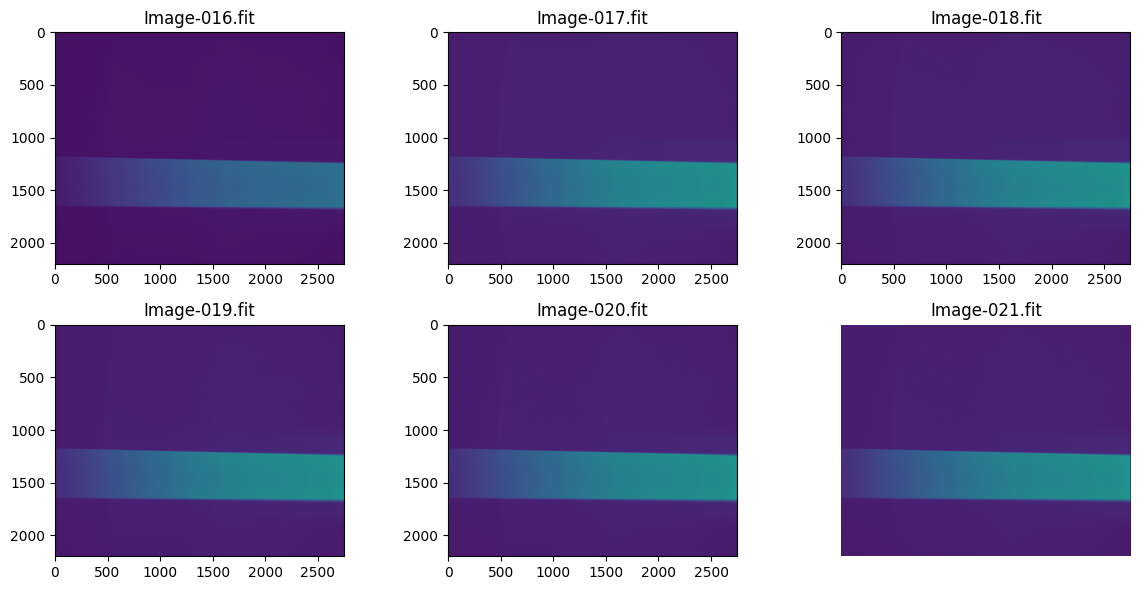

In [ ]:
plot_files_img(flat_files)

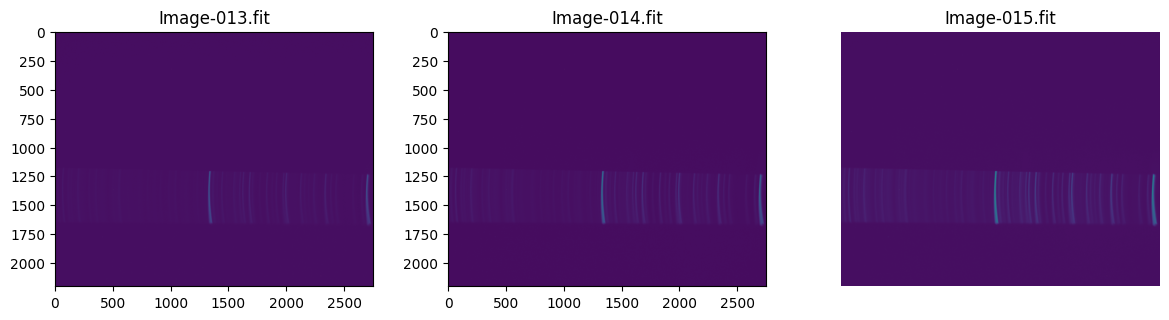

In [ ]:
plot_files_img(arc_files)

In [41]:
masterbias = np.median([fits.getdata(inputfile)[:,:-5] for inputfile in bias_files], axis=0)
masterflat_data = np.median([fits.getdata(inputfile)[:,:-5] for inputfile in flat_files], axis=0)
masterarc_data  = np.median([fits.getdata(inputfile)[:,:-5] for inputfile in arc_files], axis=0)

masterflat = (masterflat_data - masterbias)
masterarc = (masterarc_data - masterbias)

/tmp/ipykernel_25839/3365406066.py:15: RuntimeWarning: divide by zero encountered in log10
  ax[4].imshow(np.log10(masterarc))
/tmp/ipykernel_25839/3365406066.py:15: RuntimeWarning: invalid value encountered in log10
  ax[4].imshow(np.log10(masterarc))


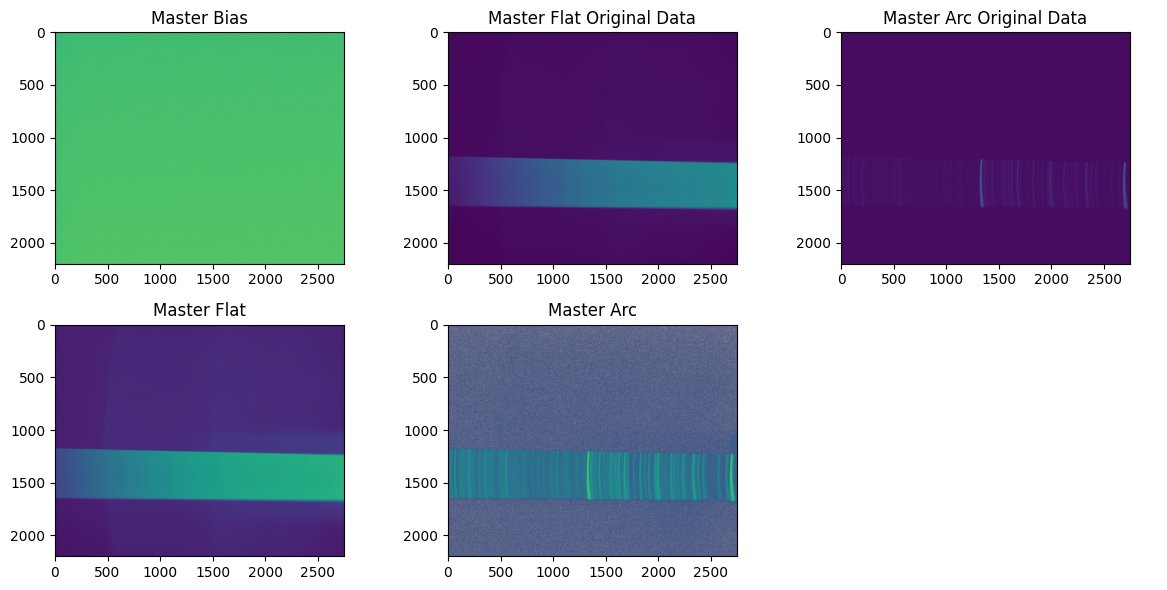

In [42]:
fig, ax = plt.subplots(2, 3, figsize=(12, 6))
ax = ax.flatten()
ax[0].imshow(np.log10(masterbias))
ax[0].set_title("Master Bias")

ax[1].imshow(np.log10(masterflat_data))
ax[1].set_title("Master Flat Original Data")

ax[2].imshow(np.log10(masterarc_data))
ax[2].set_title("Master Arc Original Data")

ax[3].imshow(np.log10(masterflat))
ax[3].set_title("Master Flat")

ax[4].imshow(np.log10(masterarc))
ax[4].set_title("Master Arc")
ax[5].axis(False)
plt.tight_layout()



Text(0.5, 1.0, 'Mask of the Master flat')

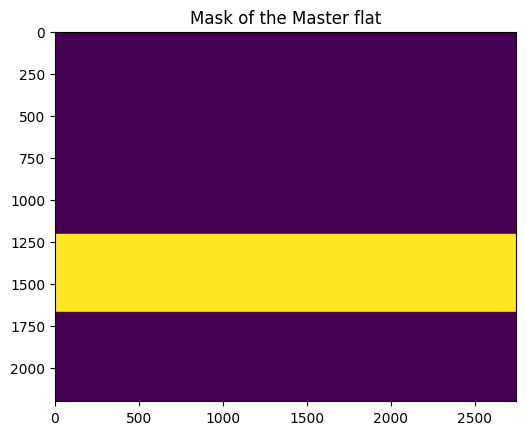

In [43]:
flat_gray = masterflat.copy()
row_mean = np.mean(flat_gray, axis=1)
rows = row_mean > np.mean(row_mean)
flat_mask = np.zeros_like(flat_gray, dtype=bool)
flat_mask[rows, :] = 255

plt.imshow(flat_mask)
plt.title("Mask of the Master flat")

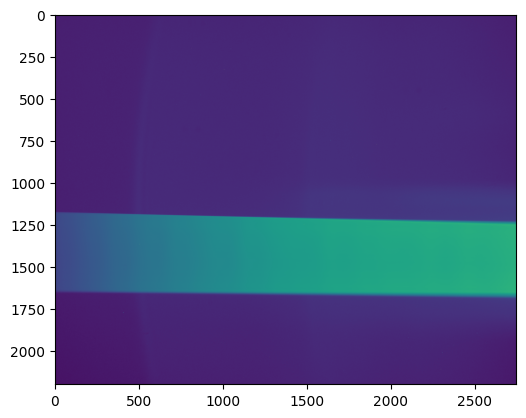

In [44]:
# Normalize the flat
masterflat_norm = masterflat / np.median(masterflat[flat_mask].flatten())
plt.imshow(np.log10(masterflat_norm))

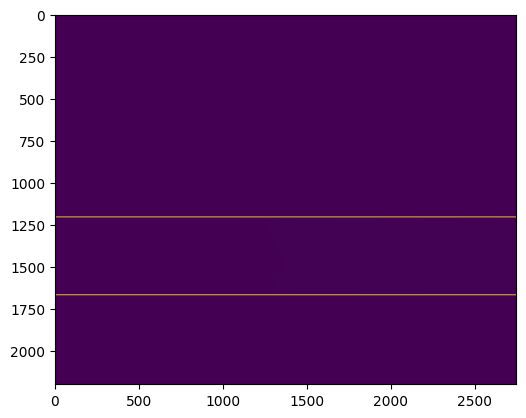

In [46]:
 # add threshold for the mask image
if len(flat_mask.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
  imgray = cv2.cvtColor(flat_mask, cv2.COLOR_BGR2GRAY)
else:
     imgray = flat_mask

imgray = (imgray * 255).astype("uint8") # <-- change image type
 _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

 # masked the original image
contours_org_img = cv2.drawContours(masterflat_norm, contours, -1, (255, 0, 0), 4)
plt.imshow((contours_org_img))

/tmp/ipykernel_25839/1086276596.py:5: RuntimeWarning: divide by zero encountered in log10
  ax[1].imshow(np.log10(flat_mask))


Text(0.5, 1.0, 'Masked image')

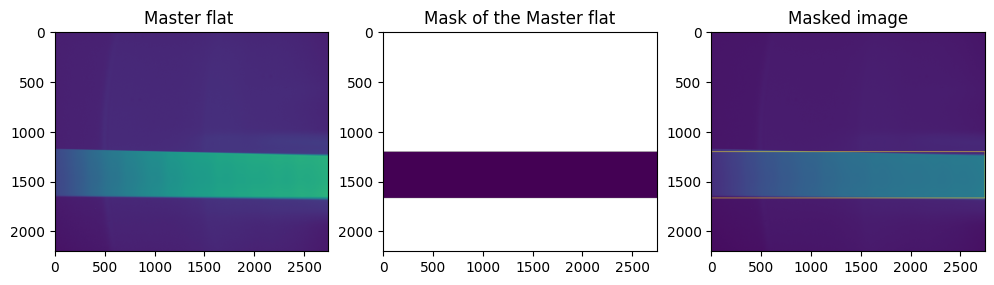

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(np.log10(masterflat))
ax[0].set_title("Master flat ")

ax[1].imshow(np.log10(flat_mask))
ax[1].set_title("Mask of the Master flat")

ax[2].imshow(np.log10(contours_org_img))
ax[2].set_title("Masked image")



In [19]:
#120 stands for the spectrum integrated with 120 seconds

science_120 = fits.getdata(path+'/science/HD3360_120s.fit')[:,:-5]
science_120 = science_120 - masterbias
science_120 = science_120 / masterflat_norm
science_120 /= 120 #To go from ADUs to ADUs/s, i.e., a rate

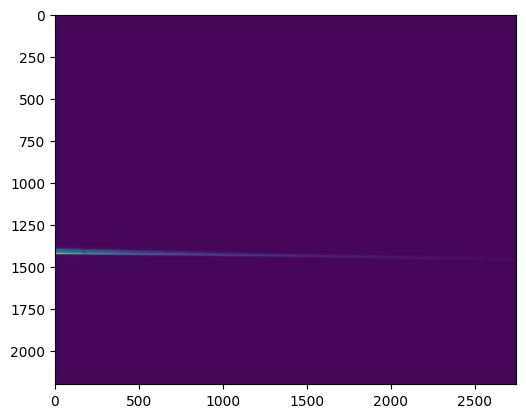

In [22]:
plt.imshow(science_120)